# Energy Investment Portfolio Selection as a 0–1 Knapsack MILP

## 1. Problem Description

An energy company has a limited capital budget and must decide which candidate energy projects to invest in.

Each project has:

- a fixed investment cost, and
- an expected annual energy production.

A project is either **selected completely** or **not selected at all**. Partial investment is not allowed.

The objective is to select the combination of projects that **maximizes total annual energy production** without exceeding the available investment budget.

This is a classic **0–1 knapsack problem**, where:

- the *knapsack capacity* is the available investment budget,
- the *weight* of each item is the project's investment cost,
- the *value* of each item is the annual energy production, and
- the binary decision indicates whether the project is selected.


## 2. Candidate Projects

The company has an investment budget of **₱100 million**.

| Project | Technology | Investment Cost (₱ million) | Annual Energy Production (GWh/year) |
|---|---|---:|---:|
| 1 | Solar Farm | 40 | 55 |
| 2 | Wind Farm | 50 | 75 |
| 3 | Small Hydro | 60 | 85 |
| 4 | Biomass Plant | 35 | 45 |
| 5 | Rooftop Solar Program | 25 | 30 |


## 3. Model Formulation

## Fixed Parameters

* $C_i$ is the *investment cost* of project $i$, in million pesos.
* $E_i$ is the expected annual *energy production* of project $i$, in GWh/year.
* $B$ is the total available investment *budget*, in million pesos. For this problem, $B = 100$.

## Decision Variables

Let $x_i$ be the discrete decision of whether a project is selected or not:

$$ x_i =
\begin{cases}
1, & \text{if project } i \text{ is selected},\\
0, & \text{otherwise.}
\end{cases}
$$

Because $x_i$ is binary, a project cannot be selected fractionally.


## Objective Function

The objective is to maximize the total annual energy production from all selected projects:

$$ \max Z = \sum_{i\in I} E_i x_i $$

From the example table above,

$$ \max Z = 55x_1 + 75x_2 + 85x_3 + 45x_4 + 30x_5. $$

## Budget Constraint

The total investment cost of the selected projects cannot exceed the available budget:

$$ \sum_{i\in I} C_i x_i \leq B. $$

For this example,

$$ 40x_1 + 50x_2 + 60x_3 + 35x_4 + 25x_5 \leq 100. $$

## Binary Restrictions

$$ x_i \in \{0,1\} \qquad \forall i\in I. $$

This makes the model a **Mixed-Integer Linear Program (MILP)**. More specifically, because all decision variables are binary, it is also a **0–1 integer linear program**.


## 4. Pyomo Implementation

In [1]:
import pyomo.environ as pyo
import pandas as pd
import matplotlib.pyplot as plt

projects = {
    1: "Solar Farm",
    2: "Wind Farm",
    3: "Small Hydro",
    4: "Biomass Plant",
    5: "Rooftop Solar Program"
}

investment_cost = {
    1: 40,
    2: 50,
    3: 60,
    4: 35,
    5: 25
}

annual_energy = {
    1: 55,
    2: 75,
    3: 85,
    4: 45,
    5: 30
}

budget = 100


## 5. Build the Pyomo Model

The binary variable `model.x[i]` represents whether project \(i\) is selected.


In [2]:
model = pyo.ConcreteModel()

# Set of projects
model.I = pyo.Set(initialize=projects.keys())

# Parameters
model.C = pyo.Param(model.I, initialize=investment_cost)
model.E = pyo.Param(model.I, initialize=annual_energy)
model.B = pyo.Param(initialize=budget)

# Binary decision variables
model.x = pyo.Var(model.I, domain=pyo.Binary)

# Objective: maximize annual energy production
def objective_rule(model):
    return sum(model.E[i] * model.x[i] for i in model.I)

model.objective = pyo.Objective(
    rule=objective_rule,
    sense=pyo.maximize
)

# Budget constraint
def budget_rule(model):
    return sum(model.C[i] * model.x[i] for i in model.I) <= model.B

model.budget_constraint = pyo.Constraint(rule=budget_rule)
model.pprint()


1 Set Declarations
    I : Size=1, Index=None, Ordered=Insertion
        Key  : Dimen : Domain : Size : Members
        None :     1 :    Any :    5 : {1, 2, 3, 4, 5}

3 Param Declarations
    B : Size=1, Index=None, Domain=Any, Default=None, Mutable=False
        Key  : Value
        None :   100
    C : Size=5, Index=I, Domain=Any, Default=None, Mutable=False
        Key : Value
          1 :    40
          2 :    50
          3 :    60
          4 :    35
          5 :    25
    E : Size=5, Index=I, Domain=Any, Default=None, Mutable=False
        Key : Value
          1 :    55
          2 :    75
          3 :    85
          4 :    45
          5 :    30

1 Var Declarations
    x : Size=5, Index=I
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          1 :     0 :  None :     1 : False :  True : Binary
          2 :     0 :  None :     1 : False :  True : Binary
          3 :     0 :  None :     1 : False :  True : Binary
          4 :     0 :  None :     1 : False

## 6. Solve the MILP

In [3]:
solver = pyo.SolverFactory("glpk")
results = solver.solve(model, tee=False)

print("Solver status:", results.solver.status)
print("Termination condition:", results.solver.termination_condition)


Solver status: ok
Termination condition: optimal


## 7. Optimal Investment Portfolio

The following table reports whether each project is selected in the optimal solution.


In [4]:
solution = []

for i in model.I:
    selected = int(round(pyo.value(model.x[i])))

    solution.append({
        "Project": projects[i],
        "Investment Cost (₱M)": investment_cost[i],
        "Annual Energy (GWh/year)": annual_energy[i],
        "Selected": selected,
        "Selected Cost (₱M)": selected * investment_cost[i],
        "Selected Energy (GWh/year)": selected * annual_energy[i]
    })

df_results = pd.DataFrame(solution)

total_cost = df_results["Selected Cost (₱M)"].sum()
total_energy = df_results["Selected Energy (GWh/year)"].sum()
unused_budget = budget - total_cost

display(df_results)

print(f"Total investment cost : ₱{total_cost:.0f} million")
print(f"Unused budget         : ₱{unused_budget:.0f} million")
print(f"Total annual energy   : {total_energy:.0f} GWh/year")


,Project,Investment Cost (₱M),Annual Energy (GWh/year),Selected,Selected Cost (₱M),Selected Energy (GWh/year)
0,Solar Farm,40,55,1,40,55
1,Wind Farm,50,75,0,0,0
2,Small Hydro,60,85,1,60,85
3,Biomass Plant,35,45,0,0,0
4,Rooftop Solar Program,25,30,0,0,0


Total investment cost : ₱100 million
Unused budget         : ₱0 million
Total annual energy   : 140 GWh/year


## Interpretation

The optimizer compares all feasible combinations of projects and selects the portfolio that gives the largest total annual energy production while satisfying

$$ \sum_i C_i x_i \leq 100. $$

Notice that the model does **not** necessarily choose the cheapest projects or the projects with the highest individual energy output. It chooses the **best combination** under the budget constraint.

This combinatorial selection behavior is what makes the problem a useful introductory example of a knapsack MILP.


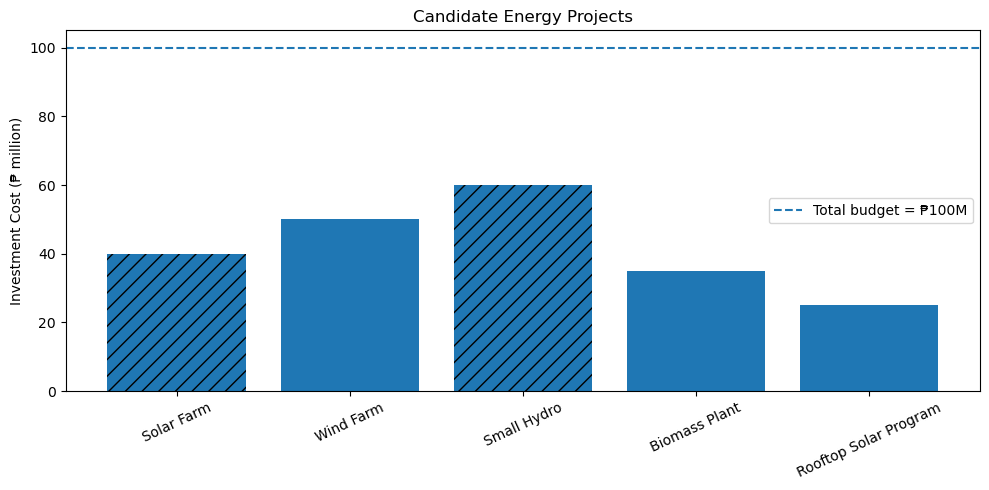

In [5]:
plot_df = df_results.copy()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    plot_df["Project"],
    plot_df["Investment Cost (₱M)"]
)

# Mark selected projects using hatching
for bar, selected in zip(bars, plot_df["Selected"]):
    if selected == 1:
        bar.set_hatch("//")

ax.axhline(
    budget,
    linestyle="--",
    linewidth=1.5,
    label=f"Total budget = ₱{budget}M"
)

ax.set_ylabel("Investment Cost (₱ million)")
ax.set_title("Candidate Energy Projects")
ax.tick_params(axis="x", rotation=25)
ax.legend()

plt.tight_layout()
plt.show()


A more direct way to visualize the portfolio is to plot only the projects that were selected.


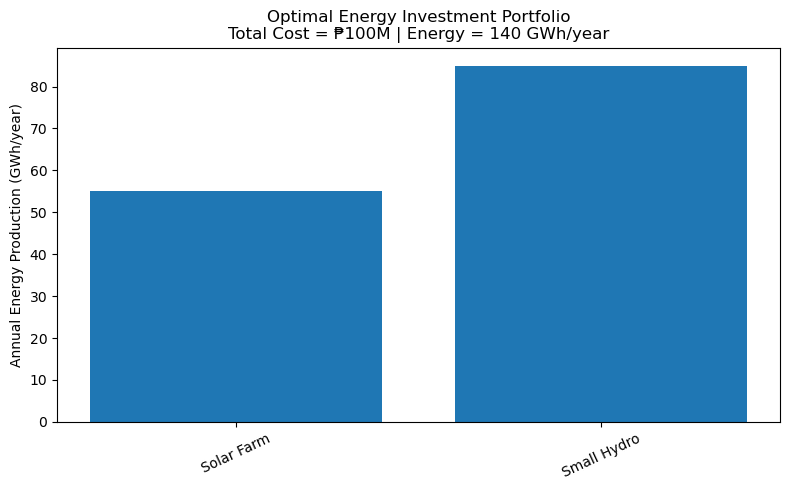

In [6]:
# -----------------------------
# Plot selected projects
# -----------------------------

selected_df = df_results[df_results["Selected"] == 1]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    selected_df["Project"],
    selected_df["Annual Energy (GWh/year)"]
)

ax.set_ylabel("Annual Energy Production (GWh/year)")
ax.set_title(
    f"Optimal Energy Investment Portfolio\n"
    f"Total Cost = ₱{total_cost:.0f}M | "
    f"Energy = {total_energy:.0f} GWh/year"
)
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## 8. Why This Is a Knapsack Problem

The correspondence with the classical 0–1 knapsack problem is:

| Classical Knapsack | Energy Investment Problem |
|---|---|
| Item | Candidate energy project |
| Item weight | Investment cost \(C_i\) |
| Item value | Annual energy production \(E_i\) |
| Knapsack capacity | Investment budget \(B\) |
| Take/not take item | Select/not select project \(x_i\) |

The essential feature is the binary decision

$$ x_i \in \{0,1\}. $$

If the variables were instead allowed to satisfy

$$ 0 \leq x_i \leq 1, $$

the model would become a **fractional knapsack LP**, where partial investment in a project would be allowed.

For most infrastructure projects, this would not be a physically meaningful interpretation, which motivates the binary MILP formulation.


## 9. Possible Extensions

This basic model can later be extended into a more realistic energy planning MILP by introducing additional constraints, for example:

### Require at least one variable renewable energy project

$$ x_{\text{solar}} + x_{\text{wind}} \geq 1 $$

### Make two projects mutually exclusive

$$ x_{\text{hydro}} + x_{\text{biomass}} \leq 1 $$

### Require one project when another is selected

For example, if a solar project requires an associated battery project,

$$ x_{\text{solar}} \leq x_{\text{battery}}. $$

These additions preserve the linear structure of the model while demonstrating how binary variables can represent logical engineering decisions.
